

# 📊 Refugee Integration and Population Change in Germany  
### 📈 Impact of the 2015 Migration Crisis

This notebook analyzes refugee trends and their impact on Germany’s population using UNHCR and World Bank data.


introduction 

 The 2015 migration crisis marked a major shift in migration patterns across Europe, with Germany receiving a large number of refugees. This development raised important questions regarding its impact on population dynamics and economic integration.

Understanding how refugee inflows affect population size and structure is essential for evaluating long-term demographic and labor market outcomes. This paper aims to analyze changes in Germany’s population following the migration crisis and to examine the scale of refugee inflows over time.

 ## Data 
     
 The analysis is based on two main datasets. Refugee statistics are obtained from the UNHCR database, which provides annual data on the number of refugees and asylum seekers in Germany. Population data is sourced from the World Bank, offering consistent information on total population levels over time.

The combined dataset covers the period from 2008 to 2023 and allows for a comparison of trends before, during, and after the migration crisis.

 ## Methology 
 
  The study applies a quantitative approach based on time series analysis. Refugee data is aggregated by year and merged with population data using the year variable as a common reference.

Additionally, the share of refugees relative to the total population is calculated to assess the demographic impact of migration. The results are visualized using line graphs to highlight trends over time.


## Results 

 The results show a sharp increase in the number of refugees in Germany during the period 2014–2016, corresponding to the migration crisis. This peak represents a significant deviation from previous years, where refugee numbers were relatively stable.

Following the crisis, the number of refugees stabilizes, indicating a transition from high inflows to a period of integration. The overall population continues to grow, partly influenced by migration.

 ## Discusion
 
The findings suggest that migration has played a key role in shaping Germany’s population trends. The sudden increase in refugee numbers during the crisis had a noticeable demographic impact, while the subsequent stabilization reflects policy adjustments and changing migration patterns.

These results highlight the importance of migration as a factor in demographic and economic development, particularly in aging societies such as Germany.

## Conclusion 
 In conclusion, the 2015 migration crisis significantly affected Germany’s population dynamics. Refugee inflows led to a temporary surge in population growth, followed by a stabilization phase.

The analysis demonstrates that migration is an important driver of demographic change and underscores the need for effective integration policies to support long-term economic outcomes.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


## Data Loading

In this step, the datasets are loaded into the notebook using the pandas library. The data is imported from CSV files for further processing.

In [3]:
unhcr = pd.read_csv("unhcr_data.csv")


In [7]:
unhcr.head()


,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Asylum-seekers,IDPs,Other people in need of international protection,Stateless persons,Host community,Others of concern
0,2006,Germany,Afghanistan,DEU,AFG,21879,3999,0,0,0,0,0
1,2006,Germany,Albania,DEU,ALB,963,160,0,0,0,0,0
2,2006,Germany,Algeria,DEU,DZA,1248,419,0,0,0,0,0
3,2006,Germany,Andorra,DEU,AND,5,0,0,0,0,0,0
4,2006,Germany,Angola,DEU,AGO,2006,381,0,0,0,0,0


In [8]:
unhcr = unhcr[unhcr["Country of Asylum"] == "Germany"]

In [19]:
unhcr = unhcr.groupby("Year")["Refugees"].sum().reset_index()


In [20]:
unhcr.columns

Index(['Year', 'Refugees'], dtype='object')

In [21]:
unhcr.head()

,Year,Refugees
0,2006,605329
1,2007,578866
2,2008,582719
3,2009,593787
4,2010,594250


In [10]:
population = pd.read_csv("population.csv", skiprows=4)

In [11]:
population.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


## Data Filtering

The population dataset includes multiple countries. Since the focus of this analysis is Germany, the dataset is filtered to include only observations related to Germany.

In [12]:
population = population[population["Country Name"] == "Germany"]

In [14]:
population = population.loc[:, ["Country Name"] + [str(year) for year in range(2008, 2024)]]

In [15]:
population = population.melt(id_vars=["Country Name"], 
                             var_name="Year", 
                             value_name="Population")

In [16]:
population["Year"] = population["Year"].astype(int)

In [17]:
population.head()

,Country Name,Year,Population
0,Germany,2008,82110097.0
1,Germany,2009,81902307.0
2,Germany,2010,81776930.0
3,Germany,2011,80274983.0
4,Germany,2012,80425823.0


## Time Filtering

The UNHCR dataset includes observations for a wider range of years. To ensure consistency with the population dataset and to focus on the relevant period of analysis, the data is restricted to the years between 2008 and 2023.

This step ensures that both datasets cover the same time frame, allowing for accurate comparison and merging.

In [22]:
unhcr = unhcr[(unhcr["Year"] >= 2008) & (unhcr["Year"] <= 2023)]

The datasets are merged using the year variable as a common key in order to combine refugee and population data for analysis.

In [23]:
data = pd.merge(unhcr, population, on="Year")


In [24]:
data.head()


,Year,Refugees,Country Name,Population
0,2008,582719,Germany,82110097.0
1,2009,593787,Germany,81902307.0
2,2010,594250,Germany,81776930.0
3,2011,571672,Germany,80274983.0
4,2012,589735,Germany,80425823.0


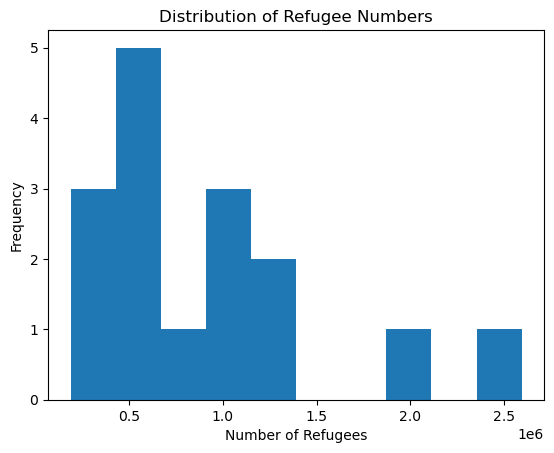

In [30]:
plt.hist(data["Refugees"], bins=10)
plt.title("Distribution of Refugee Numbers")
plt.xlabel("Number of Refugees")
plt.ylabel("Frequency")
plt.show()

## Distribution Analysis

The histogram shows the distribution of refugee numbers over the analyzed period. Most values are concentrated in a specific range, with higher values observed during the migration crisis.

The distribution of the refugee share indicates that, although there are fluctuations, the overall proportion remains relatively low. This confirms that the demographic impact of refugees is moderate relative to the total population.

In [25]:
data["refugee_share"] = data["Refugees"] / data["Population"]

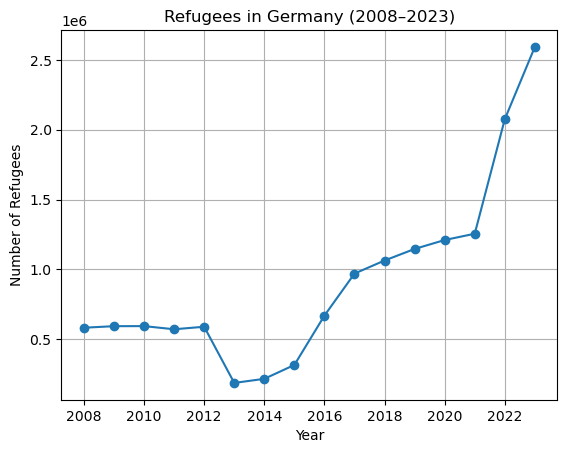

In [26]:
import matplotlib.pyplot as plt

plt.plot(data["Year"], data["Refugees"], marker="o")
plt.title("Refugees in Germany (2008–2023)")
plt.xlabel("Year")
plt.ylabel("Number of Refugees")
plt.grid()
plt.show()

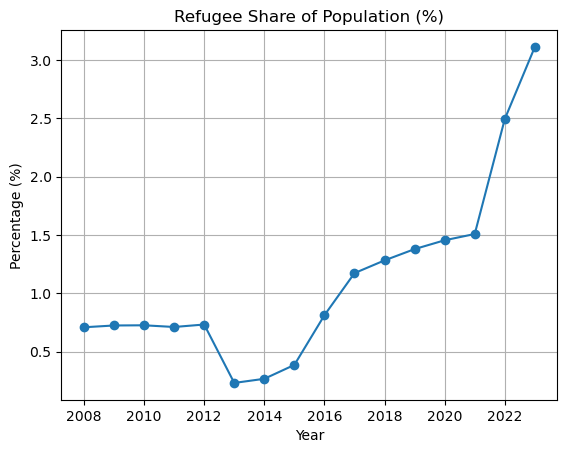

In [27]:
plt.plot(data["Year"], data["refugee_share"]*100, marker="o")
plt.title("Refugee Share of Population (%)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.grid()
plt.show()


## Distribution Analysis

In addition to the time series analysis, histograms are used to examine the distribution of refugee numbers and their share in the total population.

The distribution of refugee numbers shows that most values are concentrated at lower levels, with a smaller number of higher values corresponding to the migration crisis period around 2015–2016. This indicates that the increase in refugee numbers is not constant over time but driven by a specific event.

Similarly, the distribution of the refugee share confirms that the proportion of refugees relative to the total population remains relatively low throughout the period. Although there is a noticeable increase during the crisis, the values remain within a limited range.

Overall, the histograms support the findings from the time series analysis by showing that the migration crisis represents a temporary deviation rather than a permanent structural change.